# Data Science in Psychology and Neuroscience

## Class info:
* Week #12
* Day: April 9, 2026
* Time: 9:30—10:45 AM
* Location: Logan Hall 125
* <a href="https://forms.microsoft.com/r/26vAcJWrwH">Click here to submit your attendance for Week 12, Question 22!</a>
  
## Instructor info:
* Dr. Jeremy Hogeveen
* jhogeveen@unm.edu
* Logan Hall 281 (Office Hours By Appointment)
  
## Syllabus:
* <a href="https://www.dropbox.com/scl/fi/6fs6fi4kvkwtxn7j7x8ua/PSY450650_DSPN_Spring2026_Syllabus.pdf?rlkey=148e5t4ah8q2n1daclt7mp0h6&dl=0">Download here</a>

## Today's topic:
* Modeling our ketamine trial data, continued
1. Linear Mixed Models (LMMs).
2. Testing the assumptions of the GLM.
3. My suggestions for GLM violations: Use robust estimators.

 

In [2]:
## Preamble: loading packages and reading in the data

# package loadings
suppressPackageStartupMessages(library(tidyverse))
suppressPackageStartupMessages(library(emmeans))
suppressPackageStartupMessages(library(knitr))
suppressPackageStartupMessages(library(lme4))
suppressPackageStartupMessages(library(lmerTest))
suppressPackageStartupMessages(library(ggeffects))
suppressPackageStartupMessages(library(gridExtra))

In [4]:
# Read in our data
df <- read_csv('../data/synth_ketamine_data.csv')

# Reorder our factors accordingly
Time_desired_order <- c("Pre", "Post", "Followup")
df$Time <- factor(df$Time, levels = Time_desired_order)
Drug_desired_order <- c("Placebo", "Amphetamine", "Ketamine")
df$Drug <- factor(df$Drug, levels = Drug_desired_order)

# head(df)

Rows: 180 Columns: 5
── Column specification ─────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Drug, Time
dbl (3): Subject, Change, HAMD

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# Section 1. Linear Mixed Models

### 1.1 Running the basic LMM on our ketamine trial data
* The `R` Syntax: $HAMD$ ~ $Drug * Time + (1 | Subject)$
    * `Drug` * `Time` represents our __Fixed Effects__.
    * `(1 | Subject)` tells the model to add a __Random Intercept__ for each person.
* In plain English: "Calculate the overall, average effects of the Drug over Time, but allow every single subject to start at their own unique baseline level of depression."

In [5]:
# fit our linear mixed effects model
m_lmm <- lmer(HAMD ~ Drug * Time + (1 | Subject),df)

In [6]:
# print the omnibus table and detailed coefficients table
lmm_anova_table <- as.data.frame(anova(m_lmm))
kable(lmm_anova_table,digits=3, caption = "Omnibus Model Table from LMM")



Table: Omnibus Model Table from LMM

|          |   Sum Sq| Mean Sq| NumDF| DenDF| F value| Pr(>F)|
|:---------|--------:|-------:|-----:|-----:|-------:|------:|
|Drug      |   96.228|  48.114|     2|    57|  13.100|      0|
|Time      | 1610.668| 805.334|     2|   114| 219.263|      0|
|Drug:Time |  843.347| 210.837|     4|   114|  57.403|      0|

In [14]:
# Full model table summary
lmm_coeffs_table <- summary(m_lmm)$coefficients
kable(lmm_coeffs_table,digits=3, caption = "Coefficients Table from LMM")



Table: Coefficients Table from LMM

|                             | Estimate| Std. Error|      df| t value| Pr(>&#124;t&#124;)|
|:----------------------------|--------:|----------:|-------:|-------:|------------------:|
|(Intercept)                  |   23.997|      0.945|  75.614|  25.404|              0.000|
|DrugAmphetamine              |   -0.810|      1.336|  75.614|  -0.607|              0.546|
|DrugKetamine                 |    0.578|      1.336|  75.614|   0.433|              0.666|
|TimePost                     |   -2.046|      0.606| 114.000|  -3.376|              0.001|
|TimeFollowup                 |   -1.851|      0.606| 114.000|  -3.054|              0.003|
|DrugAmphetamine:TimePost     |   -4.200|      0.857| 114.000|  -4.900|              0.000|
|DrugKetamine:TimePost        |  -10.436|      0.857| 114.000| -12.176|              0.000|
|DrugAmphetamine:TimeFollowup |   -0.843|      0.857| 114.000|  -0.984|              0.327|
|DrugKetamine:TimeFollowup    |  -10.216| 

In [7]:
# getting conditional effects off the model object
lmm_predictions <- ggpredict(m_lmm, terms = c("Time", "Drug"))

# Should give us a nice table of predicted effects at each level of drug * time with CIs
lmm_predictions

x,predicted,std.error,conf.low,conf.high,group
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
Pre,23.99727,0.9446274,22.13248,25.86206,Placebo
Pre,23.18702,0.9446274,21.32224,25.05181,Amphetamine
Pre,24.57576,0.9446274,22.71097,26.44055,Ketamine
Post,21.95125,0.9446274,20.08647,23.81604,Placebo
Post,16.94116,0.9446274,15.07637,18.80595,Amphetamine
Post,12.09396,0.9446274,10.22917,13.95875,Ketamine
Followup,22.14667,0.9446274,20.28188,24.01145,Placebo
Followup,20.49308,0.9446274,18.62829,22.35787,Amphetamine
Followup,12.50923,0.9446274,10.64444,14.37402,Ketamine


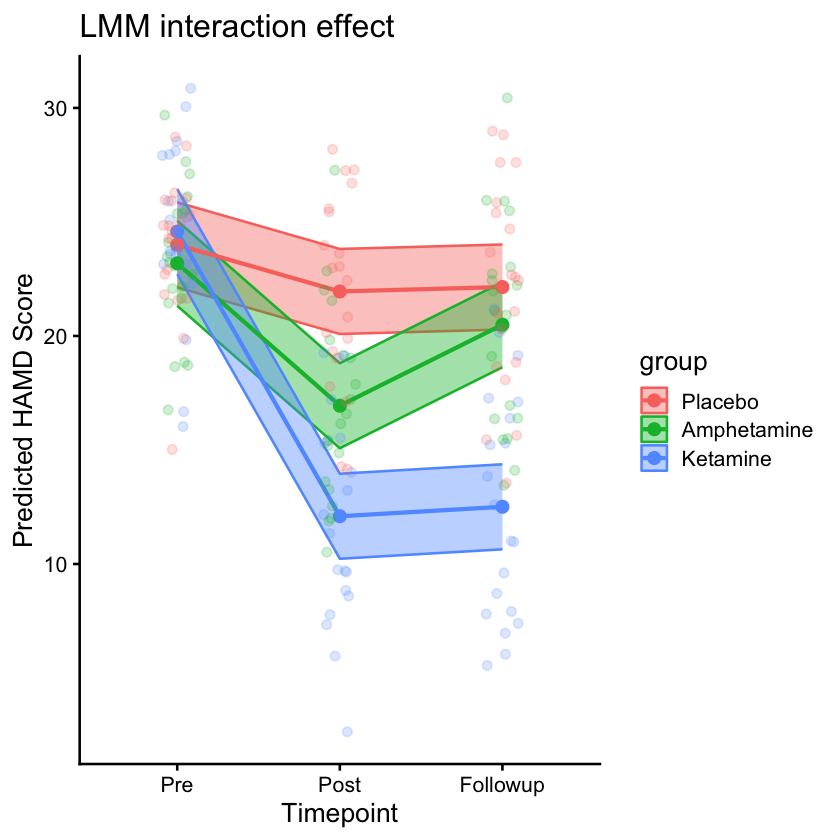

In [8]:
# Visualizing the predicted conditional effects, with a raw data jittered overlay
p_lmm_interaction <- ggplot(lmm_predictions, aes(x = x, y = predicted, color = group, fill = group, group = group)) +
    geom_ribbon(aes(ymin = conf.low, ymax = conf.high), alpha = 0.4) +
    geom_line(linewidth=1.2) +
    geom_point(size = 3) +
  ylab("Predicted HAMD Score") +
  xlab("Timepoint") +
  ggtitle("LMM interaction effect") +
  theme_classic(base_size = 16)
p_lmm_interaction <- p_lmm_interaction + geom_jitter(data = df, aes(x = Time, y = HAMD, color = Drug), alpha = 0.2, width = 0.1, inherit.aes = FALSE)
plot(p_lmm_interaction)

# Section 2. General Linear Model (GLM) Assumptions.

<img src="img/decision_tree.png" width=300>

0. Outliers & influential observations
1. Independence
2. Normality
3. Equal variances

## 2.1 Before discussing each in turn, let's "break" our data a bit.

In [9]:
df_bad <- read_csv('../data/synth_ketamine_data_wskew.csv')

# Reorder our factors accordingly
df_bad$Time <- factor(df_bad$Time, levels = Time_desired_order)
df_bad$Drug <- factor(df_bad$Drug, levels = Drug_desired_order)

# Re-running the model with the bad data
m_lmm_baddata <- lmer(HAMD ~ Drug * Time + (1 | Subject), data = df_bad)

Rows: 180 Columns: 5
── Column specification ─────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Drug, Time
dbl (3): Subject, Change, HAMD

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


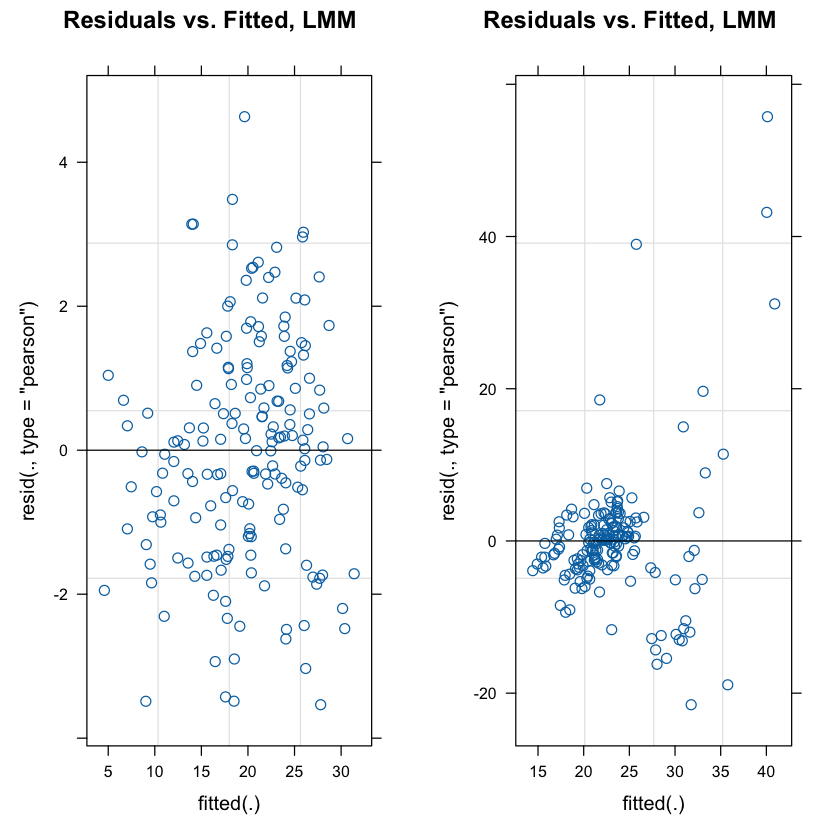

In [11]:
# Let's visualize the damage
p_residuals_clean_data <- plot(m_lmm,main="Residuals vs. Fitted, LMM")
p_residuals_bad_data <- plot(m_lmm_baddata,main="Residuals vs. Fitted, LMM")
grid.arrange(p_residuals_clean_data,
             p_residuals_bad_data,
             ncol=2)

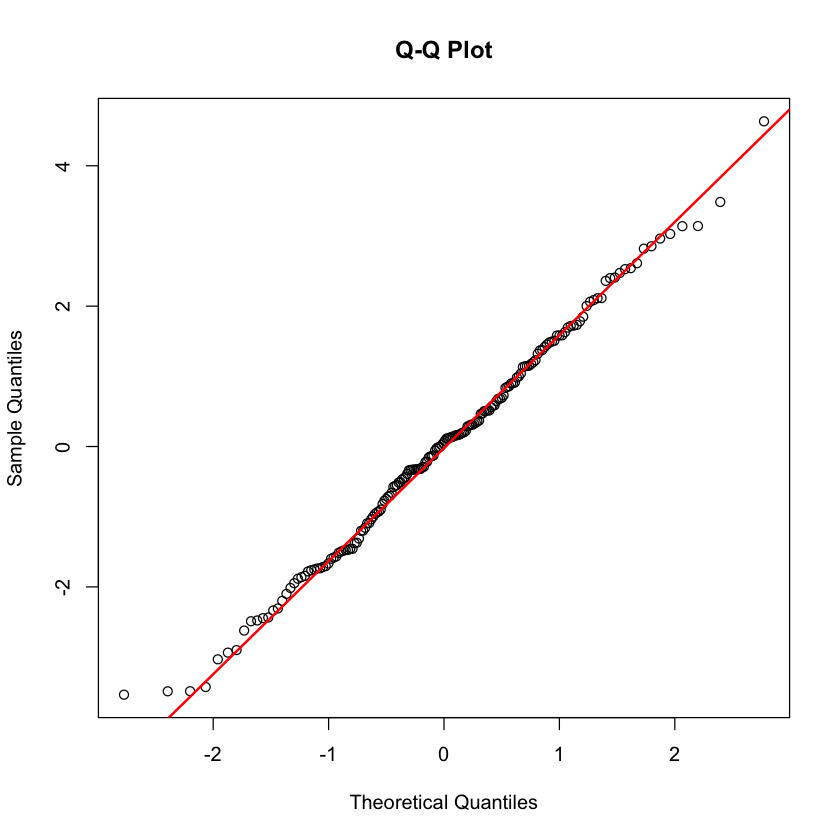

In [13]:
# QQ normality plots
qqnorm(resid(m_lmm),main = "Q-Q Plot")
qqline(resid(m_lmm), col = "red", lwd = 2)

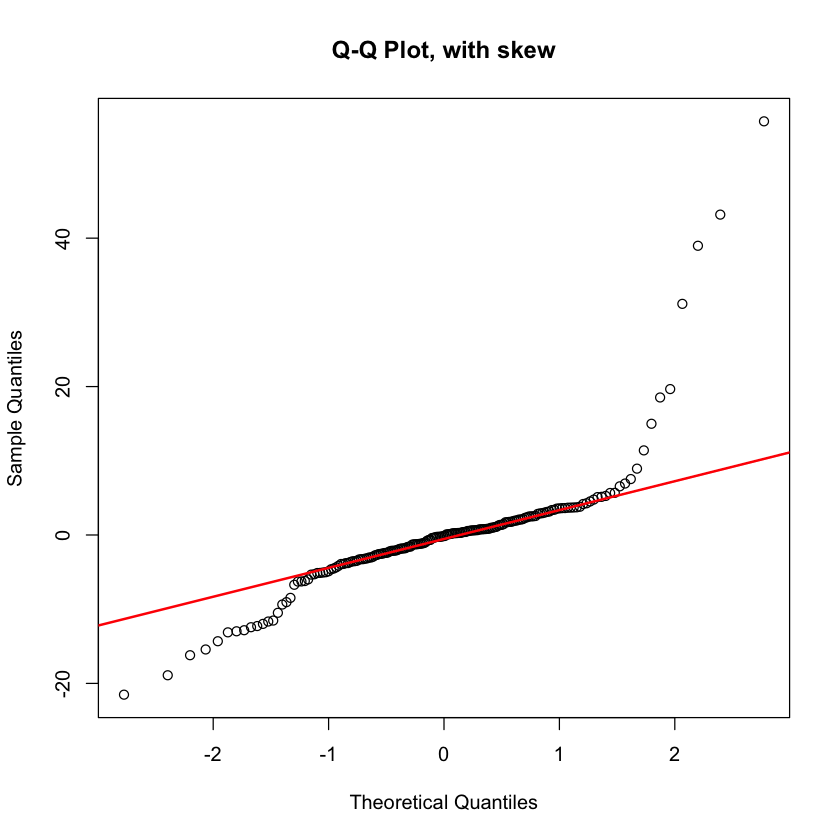

In [14]:
# QQ normality plots for the skewed data
qqnorm(resid(m_lmm_baddata),main = "Q-Q Plot, with skew")
qqline(resid(m_lmm_baddata), col = "red", lwd = 2)

### 2.2 Hunting for influential observations and outliers

* Outliers:

In [22]:
df_outliers <- df_bad %>%
    mutate(zres = as.numeric(scale(resid(m_lmm_baddata))),
           outliers = ifelse(abs(zres) >= 3, as.character(Subject),"")) %>%
    select(Subject, Drug, zres, outliers)

print(df_outliers %>% filter(outliers != ""))

# A tibble: 4 × 4
  Subject Drug      zres outliers
    <dbl> <fct>    <dbl> <chr>   
1       6 Ketamine  4.55 6       
2      11 Ketamine  3.63 11      
3      12 Ketamine  5.04 12      
4      16 Ketamine  6.50 16      


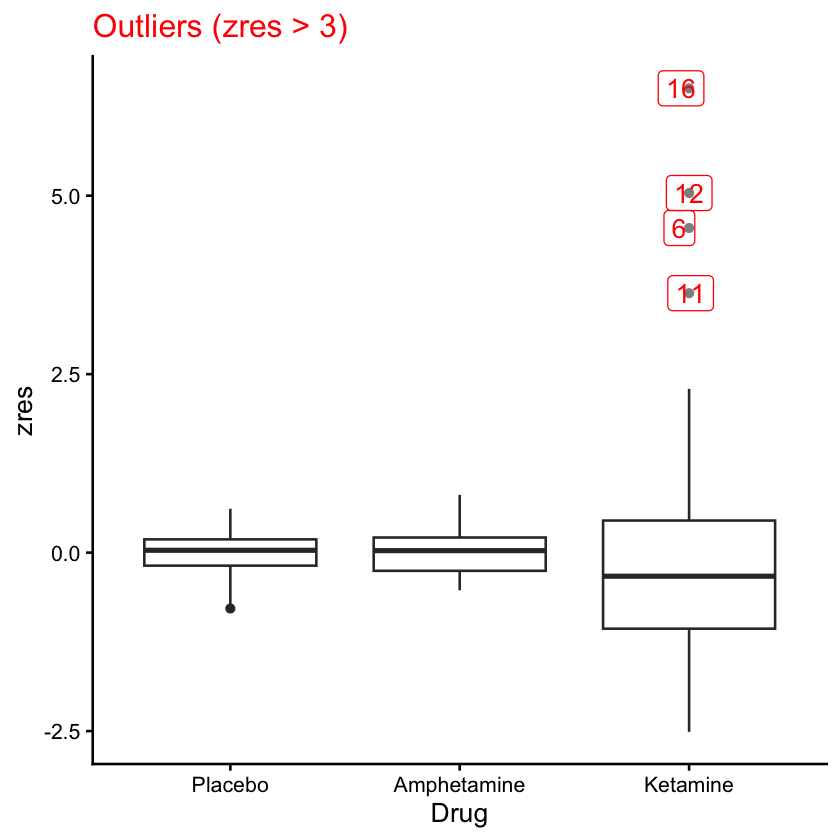

In [23]:
dodge <- position_jitterdodge(jitter.width = 0.2, dodge.width = 0.6)

# plotting the zres
p_outliers <- ggplot(df_outliers, aes ( x = Drug, y = zres)) +
    geom_boxplot() +
    geom_label( data  = filter(df_outliers, outliers != ""),
               aes(label = outliers), 
               color = "red", fill = "white", position = dodge, alpha = 0.4) +
    theme_classic(base_size = 16) +
    ggtitle("Outliers (zres > 3)") +
    theme(plot.title = element_text( color = "red"))
p_outliers

* Influential Observations:

In [26]:
df_influence <- df %>% # sub hatvalues (>2 h bar) for cooks.distance if continuous
    mutate(cooks_d = cooks.distance(m_lmm_baddata),
           inf_obs = ifelse(cooks_d > 0.5, as.character(Subject), "")) %>%
    select(Subject, Drug, Time, cooks_d, inf_obs)

print(df_influence %>% filter(inf_obs != ""))
           

# A tibble: 2 × 5
  Subject Drug     Time  cooks_d inf_obs
    <dbl> <fct>    <fct>   <dbl> <chr>  
1      12 Ketamine Post    0.582 12     
2      16 Ketamine Post    0.971 16     


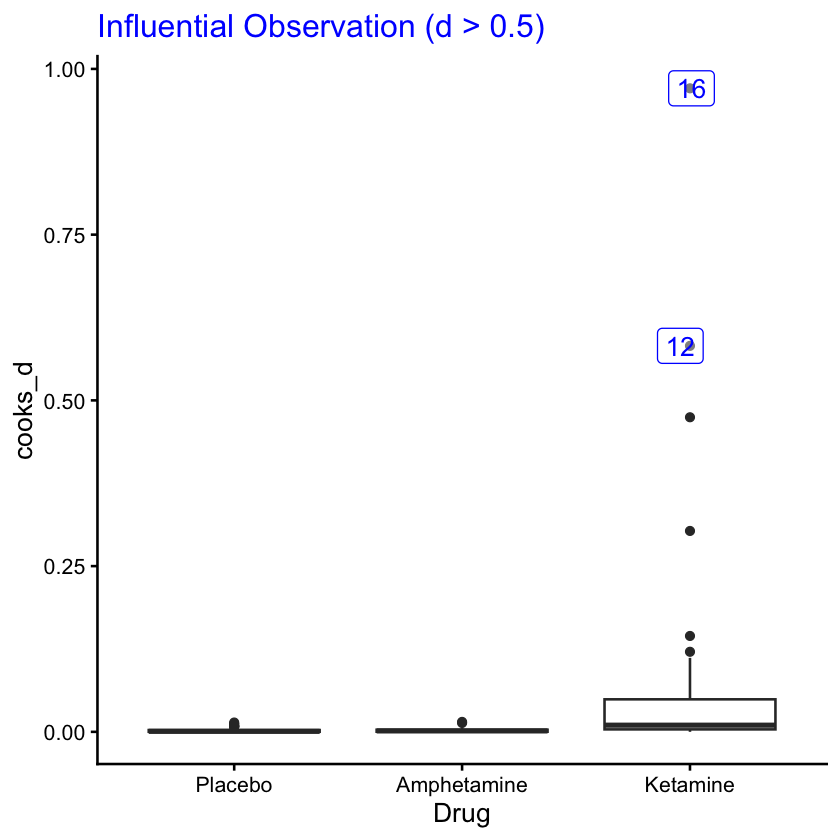

In [27]:
# plotting the cook's d
p_influence <- ggplot(df_influence, aes ( x = Drug, y = cooks_d)) +
    geom_boxplot() +
    geom_label( data  = filter(df_influence, inf_obs != ""),
               aes(label = inf_obs), 
               color = "blue", fill = "white", position = dodge, alpha = 0.4) +
    theme_classic(base_size = 16) +
    ggtitle("Influential Observation (d > 0.5)") +
    theme(plot.title = element_text( color = "blue"))
p_influence

### 2.3 GLM Assumptions: 


#### Independence
* ___Observations are independent of each other___
* Repeated-measures designs
    * e.g. within-subject observations across time often show "serial correlation" or "autocorrelation"
* Nested designs (e.g. workers on a team, team within a department, departments within an org.)
* For `lm`, use `durbinWatsonTest(model)`
* For `lmer`, check the residuals plot

#### Normality
* ___There is an assumption that the data are normally distributed___
* Most datasets contain at least one non-gaussian variable...
    * That doesn't _necessarily_ matter. The key is: Are the model error terms (i.e., residuals) normally distributed?
* For `lm`, use `shapiro.test(model)`
* For `lmer`, check the residuals plot

#### Equal variances 
* ___Across different types of GLM-family tests, there are common assumptions about equal variances___
* Homogeneity of variance: Differences, single predictor variable (e.g. t.test, one-way ANOVA)
* Sphericity: Differences, multilevel factor(s) (e.g. repeated-measures and mixed model ANOVA)
* Homoscedasticity: Continuous, do predictor variables have similar variance (e.g. multiple regression)
* For ...
    * `t.test`, use `var.test`
    * `anova`, use `bartlett.test`
    * `lm`, use `car::ncvTest`
* For `lmer`, check the residuals plot

# Section 3. Robust testing

## 3.1 Pros / Cons of different approaches

| Type of Model | Distribution Assumptions | Characteristics | Sensitivity to violations |
| --- | --- | --- | --- |
| parametric | specific, inflexible | optimal when assumptions are met | High |
| robust | parametric, allowing some flexibility | good performance in many situations | Moderate |
| nonparametric | No assumptions | Sub-optimal, but acceptable across almost any distribution | Not at all |

* Data science in practice: 
    * If assumptions not violated, use standard parametric models. 
    * If violated a bit (often the case in psych and neuro) use robust variants.
    * If your data are _truly_ wacky, use nonparametric models.
   
## 3.2 Useful resources for robust testing:
* For a thoughtful discussion on these issues: <a href="https://www.sciencedirect.com/science/article/pii/S0005796717301067">Field, A. P., & Wilcox, R. R. (2017). Behaviour research and therapy, 98, 19-38.</a>
* For a walk-through of robust methods for simpler models (regression, t.test, anova), <a href="https://github.com/hogeveen-lab/DSPN_Fall2023_Git/blob/15cf6111a3ffd7323a13598675a3cc83088bb09e/dspn_fall2023_lecture19_modeling4.ipynb">click here</a>

## 3.3 `robustlmm`
* Contains the `rlmer` function, a robust equivalent of `lmer` for LMMs.
* `lmer` relies on Restricted Maximum Likelihood estimation (REML), which is highly sensitive to extreme values and GLM assumption violations.
* `rlmer` uses a robust approach that down-weights outliers, ensuring they don't disproportionaly skew the model estimates.
* Computational restriction: `rlmer` relies on complex iterative reweighting algorithm, and takes a long time for large datasets. Might be worth avoiding unless you _need_ to use it!
* Model family restriction: `rlmer` can only be used to supplant `lmer` for continuous outcome variables.
    * If running mixed models for Binomial (logistic), Poisson (counts), Gamma or inverse Gaussian (positive, zero-inflated values), no straightforward robust equivalent.
 
### 3.3a Loading packages and creating some custom functions

In [28]:
# loading robustlmm
suppressPackageStartupMessages(library(robustlmm))

In [29]:
# creating some custom functions for omnibus anova table,
# Wald Confidence Intervals,
# and p-value computation from robustlmm.

# Building the omnibus ANOVA table for robust LMM objects
f_rlmer_anova <- function(object, data) {
    # Build a custom grid using the robust fixed effects and robust variance matrix.
    rg <- qdrg(formula = formula(object), 
               data = data, 
               coef = fixef(object), 
               vcov = as.matrix(vcov(object)),
               df = Inf) # Sets degrees of freedom to infinity to force a Wald Chi-Square test 
    # Generate the Omnibus ANOVA table (tests main effects and interactions)
    omnibus_table <- joint_tests(rg)
    return(omnibus_table)
}

# Code for generating wald confidence intervals for rlmer
f_rlmer_confint <- function(object, level = 0.95) {
  # Extract beta coefficients
  beta <- fixef(object)
  # Extract names of coefficients
  parm <- names(beta)
  # Extract standard errors for the coefficients
  se <- sqrt(diag(vcov(object)))
  # Set level of confidence interval
  z <- qnorm((1 + level) / 2)
  # Calculate CI
  ctab <- cbind(beta - (z * se), 
                beta + (z * se))
  # label column names
  colnames(ctab) <- c(paste(100 * ((1 - level) / 2), '%'),
                      paste(100 * ((1 + level) / 2), '%'))
  # Output
  return(ctab[parm, ])
}

# Code for getting p-values from rlmer
f_rlmer_pvals <- function(lmer_object,rlmer_object) {
  # get coefficients from non-robust model to extract Satterthwaite approximated DFs
  coefs <- data.frame(coef(summary(lmer_object)))
  # get coefficients from robust model to extract t-values
  coefs.robust <- coef(summary(rlmer_object))
  # calculate p-values based on robust t-values and non-robust approx. DFs
  p.values <- 2*pt(abs(coefs.robust[,3]), coefs$df, lower=FALSE)
  return(p.values)
}

### 3.3b Running the model, and showing model inferences

In [30]:
# robust lmm on opur bad dataset
m_rlmm_baddata <- rlmer(HAMD ~ Drug * Time + (1 | Subject), df_bad)

In [33]:
# omnibus ANOVA style table
robust_anova_table <- f_rlmer_anova(m_rlmm_baddata, df_bad)
# output the clean table
kable(as.data.frame(robust_anova_table),
      digits = 3,
      caption = "Omnibus ANOVA (Wald Tests) from Robust-LMM")



Table: Omnibus ANOVA (Wald Tests) from Robust-LMM

|   |model term | df1| df2| F.ratio|  Chisq| p.value|
|:--|:----------|---:|---:|-------:|------:|-------:|
|1  |Drug       |   2| Inf|   1.668|  3.336|   0.189|
|3  |Time       |   2| Inf|  33.670| 67.340|   0.000|
|2  |Drug:Time  |   4| Inf|   8.173| 32.692|   0.000|

In [35]:
# Full coefficients table
robust_coefficients_table <- summary(m_rlmm_baddata)$coefficients
# output the clean table
kable(robust_coefficients_table,
      digits = 3,
      caption = "Full LMM Fixed Effects from Robust-LMM")



Table: Full LMM Fixed Effects from Robust-LMM

|                             | Estimate| Std. Error| t value|
|:----------------------------|--------:|----------:|-------:|
|(Intercept)                  |   23.964|      1.135|  21.105|
|DrugAmphetamine              |   -0.896|      1.606|  -0.558|
|DrugKetamine                 |    0.402|      1.606|   0.250|
|TimePost                     |   -2.008|      0.901|  -2.229|
|TimeFollowup                 |   -1.812|      0.901|  -2.012|
|DrugAmphetamine:TimePost     |   -4.238|      1.274|  -3.328|
|DrugKetamine:TimePost        |   -1.268|      1.274|  -0.996|
|DrugAmphetamine:TimeFollowup |   -0.882|      1.274|  -0.692|
|DrugKetamine:TimeFollowup    |   -4.262|      1.274|  -3.347|

In [36]:
# confidence intervals for robust lmm
robust_confidence_intervals <- f_rlmer_confint(m_rlmm_baddata)
# output the clean table
kable(robust_confidence_intervals,
      digits = 3,
      caption = "Condfidence intervals from Robust-LMM")



Table: Condfidence intervals from Robust-LMM

|                             |  2.5 %| 97.5 %|
|:----------------------------|------:|------:|
|(Intercept)                  | 21.739| 26.190|
|DrugAmphetamine              | -4.043|  2.252|
|DrugKetamine                 | -2.746|  3.549|
|TimePost                     | -3.773| -0.243|
|TimeFollowup                 | -3.578| -0.047|
|DrugAmphetamine:TimePost     | -6.734| -1.742|
|DrugKetamine:TimePost        | -3.765|  1.228|
|DrugAmphetamine:TimeFollowup | -3.378|  1.615|
|DrugKetamine:TimeFollowup    | -6.759| -1.766|

In [37]:
# p values
robust_p_values <- f_rlmer_pvals(m_lmm_baddata,m_rlmm_baddata)
# Output the clean table
kable(as.data.frame(robust_p_values), 
      digits = 3, 
      caption = "Robust LMM Fixed Effects, p-values")



Table: Robust LMM Fixed Effects, p-values

|                             | robust_p_values|
|:----------------------------|---------------:|
|(Intercept)                  |           0.000|
|DrugAmphetamine              |           0.578|
|DrugKetamine                 |           0.803|
|TimePost                     |           0.028|
|TimeFollowup                 |           0.047|
|DrugAmphetamine:TimePost     |           0.001|
|DrugKetamine:TimePost        |           0.321|
|DrugAmphetamine:TimeFollowup |           0.490|
|DrugKetamine:TimeFollowup    |           0.001|

### 3.3c Checking model residuals

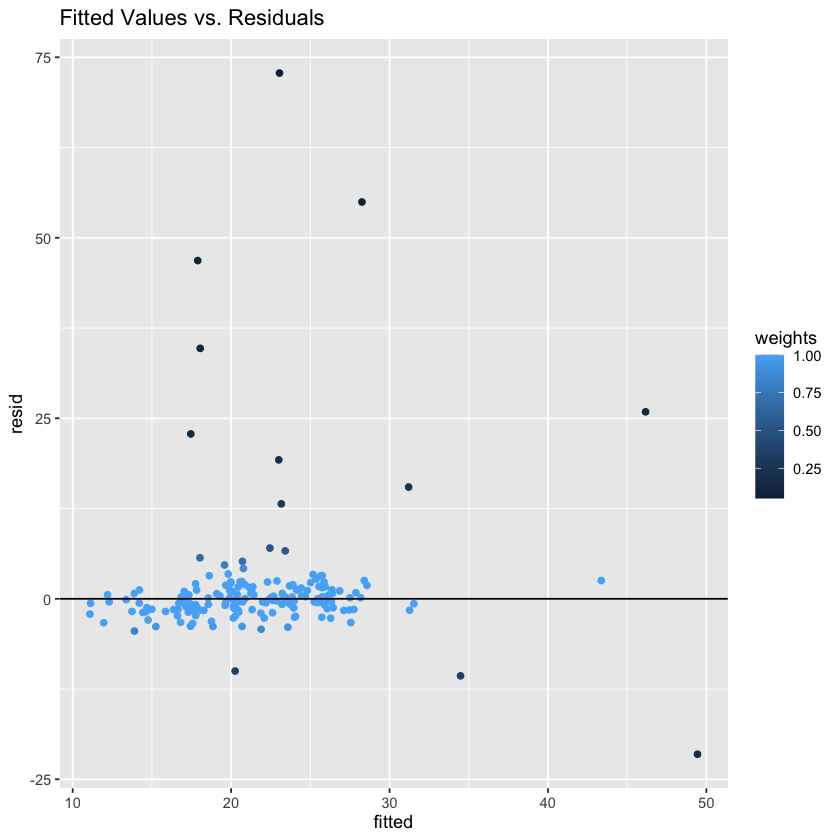

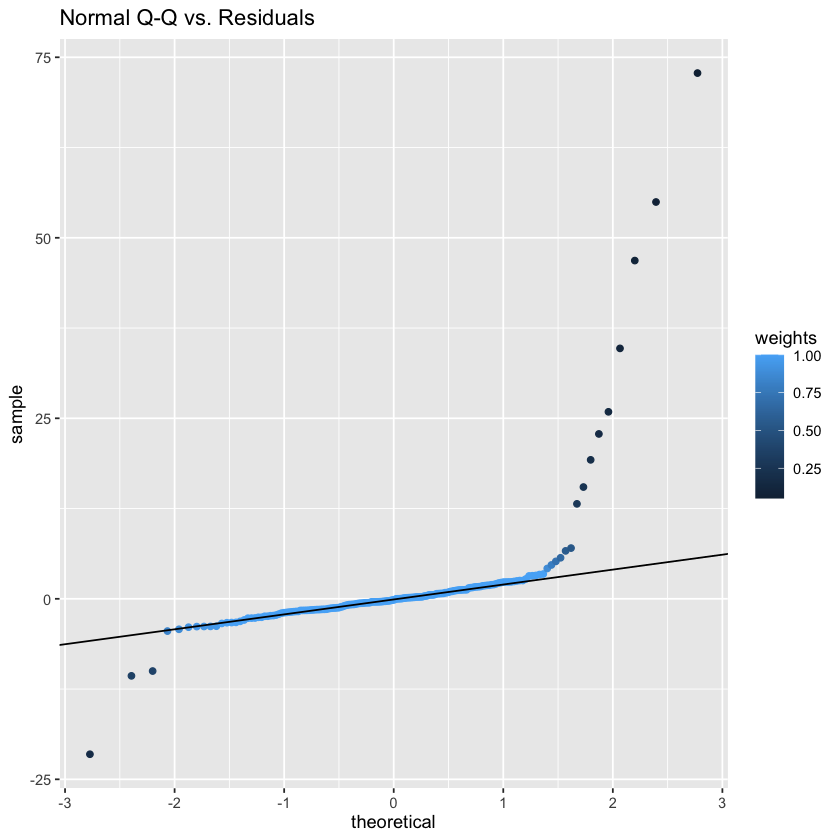

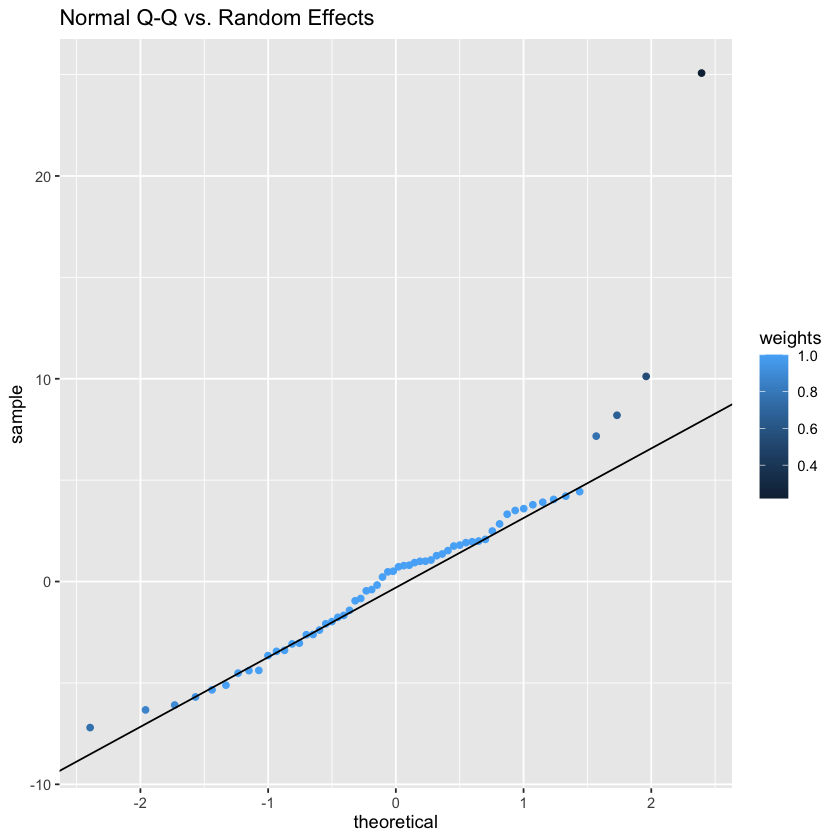

In [40]:
plot(m_rlmm_baddata)

# Section 4. Parting thoughts.

1. Let your research question and data structure drive your model choice.
2. Omnibus tests control for error and maximize power.
3. Linear mixed models (LMMs) offer flexibility and power.
4. Distinguish between _fixed_ and _random_ effects.
5. Always check your GLM assumptions.
6. Use robust (or Bayesian) estimation when you have GLM violations.